In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [15]:
def extract_color_features(image):

    mean = cv2.mean(image)[:3]

    return np.array(mean)

In [16]:
def extract_shape_features(gray):

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)

    return np.array([edge_count])

In [27]:
def extract_texture_features(gray):

    radius = 1
    n_points = 8 * radius

    lbp = local_binary_pattern(
        gray,
        n_points,
        radius,
        method='uniform'
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")

    hist /= (hist.sum() + 1e-6)

    return hist

In [25]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [38]:
dataset_path = "dataset/data"
image_size = 128

In [28]:
features = []
labels = []

In [39]:
for label in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, label)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file)

        image = cv2.imread(image_path)

        if image is None:
            continue

        # Resize
        image = cv2.resize(image, (image_size, image_size))

        # Normalize
        image = image / 255.0

        # Convert back for OpenCV
        image_uint8 = (image * 255).astype("uint8")

        # Grayscale
        gray = cv2.cvtColor(
            image_uint8,
            cv2.COLOR_BGR2GRAY
        )

        # Feature Extraction
        color_features = extract_color_features(image_uint8)

        shape_features = extract_shape_features(gray)

        texture_features = extract_texture_features(gray)

        # Combine Features
        combined_features = np.hstack([
            color_features,
            shape_features,
            texture_features
        ])

        features.append(combined_features)

        labels.append(label)

In [40]:
X = np.array(features)
y = np.array(labels)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (7553, 14)
Label Shape: (7553,)


In [41]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
models = {

    "SVM": SVC(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier()

}

In [44]:
scores = {}

for name, model in models.items():

    print("\n===================")
    print("Training:", name)
    print("===================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    scores[name] = acc

    print("Accuracy:", acc)

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n")

    print(confusion_matrix(y_test, y_pred))


Training: SVM
Accuracy: 0.6419589675711449

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.61      0.63       761
           1       0.63      0.68      0.65       750

    accuracy                           0.64      1511
   macro avg       0.64      0.64      0.64      1511
weighted avg       0.64      0.64      0.64      1511


Confusion Matrix:

[[461 300]
 [241 509]]

Training: Random Forest
Accuracy: 0.8352084712111185

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.83      0.84       761
           1       0.83      0.84      0.83       750

    accuracy                           0.84      1511
   macro avg       0.84      0.84      0.84      1511
weighted avg       0.84      0.84      0.84      1511


Confusion Matrix:

[[635 126]
 [123 627]]

Training: KNN
Accuracy: 0.6803441429516877

Classification Report:

              precision    recall  f1-score

In [45]:
best_model = max(scores, key=scores.get)

print("Best Model:", best_model)

print("Best Accuracy:", scores[best_model])

Best Model: Random Forest
Best Accuracy: 0.8352084712111185


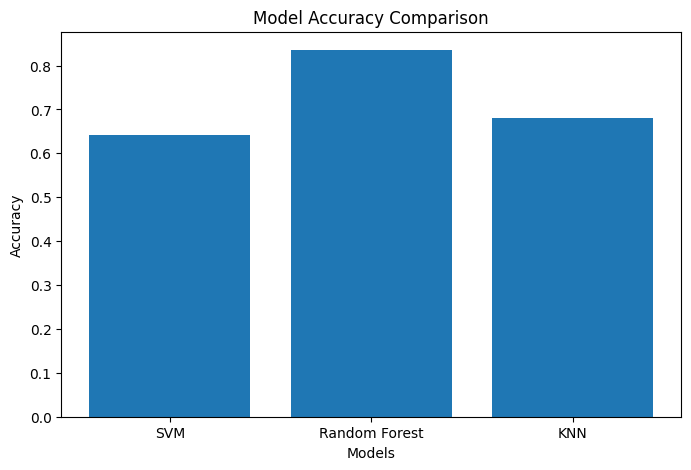

In [46]:
plt.figure(figsize=(8,5))

plt.bar(scores.keys(), scores.values())

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()